In [32]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [33]:
load_dotenv()

True

In [34]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

In [35]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [36]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [37]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

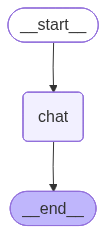

In [38]:
app

In [39]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [40]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='c92bba87-14d2-4be5-a782-9dbeb7325e0c')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='42fa4af4a2260116c95ed39b837eeb0e')]}

In [41]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [42]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [43]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

APIStatusError: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 4096 tokens, but can only afford 3597. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'provider_name': None}}, 'user_id': 'user_366aHQuTxMr7aTT1584O8i59mnO'}

In [ ]:
print(final_result["messages"][-1].content)

Gradient descent is a method used to find the minimum value of a function by iteratively moving in the direction of steepest descent. This is done by calculating the gradient of the function at a given point and then updating the point by taking a step in the opposite direction of the gradient. This process is repeated until the minimum value of the function is found.
